# Identifying Problem Stocks
In this notebook I will identify potential outlier stocks that show abnormal return 
trends with disproportional risk.

Black swan events such as the 2008 financial crisis, COVID-19, the dotcom bubble burst,
GameStop bull run may be legitimate reasons for outlier returns.

However, sometimes financial data may be corrupted for illegitimate reasons including,
double counting, acquisitions & mergers, bankruptcies etc.

It is important to identify potentially corrupted data so that it does not intefere with
algorithm testing and signal generation.

## Imports

In [1]:
import pandas as pd
import numpy as np
import random
from matplotlib import pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import date
from dateutil.relativedelta import relativedelta

from trading_algos import optimization as tao
from trading_algos import datasets as tad
from trading_algos import plots as tap
from trading_algos import utils as tau
from trading_algos.utils import head_tail as ht

%load_ext autoreload
%autoreload 2

2026-06-05 14:40:56.839 | INFO     | trading_algos.config:<module>:11 - PROJ_ROOT path is: /home/jamie/code/JamieW365/trading_algos


## Load Data

In [2]:
# Load a complete collection of S&P500 stocks from repository
# Not interested in survivors here
df_stocks = tad.get_sp500(survivors=False)

In [3]:
df_stocks = df_stocks.loc['2010':'2020']

In [4]:
ht(df_stocks)

Price            Close                                                \
Ticker               A         AA        AAL         AAP        AAPL   
Date                                                                   
2010-01-04   19.856192  35.301846   4.496876   34.742359    6.412383   
2010-01-05   19.640495  34.199326   5.005957   34.535843    6.423470   
2010-01-06   19.570711  35.980328   4.798554   34.836975    6.321296   
2020-12-29  113.111557  21.017693  15.860000  139.215088  131.166779   
2020-12-30  113.265923  21.885479  16.150000  140.076889  130.048386   
2020-12-31  114.327286  21.980843  15.770000  139.943588  129.046646   

Price                                                        ...    Volume  \
Ticker           ABBV        ABNB ABS        ABT       ACGL  ...       XOM   
Date                                                         ...             
2010-01-04        NaN         NaN NaN  18.321970   7.601905  ...  27809100   
2010-01-05        NaN         NaN NaN  18.173939   7.576549  ...  30174700   
2010-01-06        NaN         NaN NaN  18.274876   7.543795  ...  35044700   
2020-12-29  85.467804  150.000000 NaN  98.475838  33.566719  ...  20287700   
2020-12-30  85.933098  148.429993 NaN  98.575844  33.832970  ...  23807300   
2020-12-31  87.467766  146.800003 NaN  99.530312  34.298908  ...  22786500   

Price                                                                       \
Ticker           XRAY      XRX       XYL         XYZ        YUM        ZBH   
Date                                                                         
2010-01-04  1051400.0  5112890       NaN         NaN  2962274.0   805872.0   
2010-01-05   763400.0  3255844       NaN         NaN  3298757.0  1769643.0   
2010-01-06  1595100.0  2634375       NaN         NaN  4178981.0  1315619.0   
2020-12-29   458300.0  1488500  501900.0  15453100.0  1818300.0   757771.0   
2020-12-30   527500.0  1092600  418200.0   9837000.0  1267900.0   440428.0   
2020-12-31   607100.0  1514100  504200.0   6872400.0  1651700.0   514176.0   

Price                                        
Ticker          ZBRA        ZION        ZTS  
Date                                         
2010-01-04  168800.0   3974600.0        NaN  
2010-01-05  168800.0   5605500.0        NaN  
2010-01-06  385300.0  12615200.0        NaN  
2020-12-29  185500.0   1084100.0  1188400.0  
2020-12-30  166100.0    728400.0  1009000.0  
2020-12-31  176500.0    736300.0  1292600.0  

[6 rows x 3300 columns]

In [5]:
df_stocks.shape

(2769, 3300)

In [6]:
print(df_stocks.columns.get_level_values(1).nunique(), 'stocks')

660 stocks


## Identifying Outliers

In [7]:
log_prices = np.log(df_stocks.Close)
ht(log_prices)

Ticker,A,AA,AAL,AAP,AAPL,ABBV,ABNB,ABS,ABT,ACGL,...,XOM,XRAY,XRX,XYL,XYZ,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,2.988516,3.563935,1.503383,3.547960,1.858231,NaN,NaN,NaN,2.908101,2.028399,...,3.627827,3.384530,2.362580,NaN,NaN,2.914239,3.945952,3.355851,2.283970,NaN
2010-01-05,2.977594,3.532206,1.610629,3.541998,1.859959,NaN,NaN,NaN,2.899989,2.025058,...,3.631724,3.372571,2.363738,NaN,NaN,2.910814,3.977117,3.354106,2.318621,NaN
2010-01-06,2.974034,3.582972,1.568315,3.550679,1.843924,NaN,NaN,NaN,2.905527,2.020725,...,3.640330,3.379138,2.354436,NaN,NaN,2.903639,3.976794,3.346389,2.402003,NaN
2020-12-29,4.728375,3.045365,2.763800,4.936020,4.876470,4.448140,5.010635,NaN,4.589811,3.513535,...,3.511756,3.826501,2.816880,4.538675,5.365976,4.597686,4.956380,5.935000,3.577968,5.045283
2020-12-30,4.729738,3.085823,2.781920,4.942191,4.867907,4.453569,5.000113,NaN,4.590826,3.521436,...,3.519720,3.830591,2.826979,4.551356,5.398344,4.598234,4.954870,5.949991,3.588435,5.052308
2020-12-31,4.739065,3.090171,2.758109,4.941239,4.860174,4.471270,4.989071,NaN,4.600462,3.535114,...,3.510544,3.847929,2.840000,4.561329,5.382842,4.589522,4.967080,5.951502,3.593512,5.059768


In [8]:
# 3 Month Rolling Returns
log_returns = log_prices - log_prices.shift(63)

# Calculate Log Risk / Return
df_agg = log_returns.agg({'mean', 'std'}).rename({'mean': 'Return', 'std': 'Risk'}).T

# Annualize Log Risk / Return
df_agg = df_agg * (np.sqrt(4), 4)

In [9]:
# Calculate Thresholds For Outliers
lq = df_agg.quantile(0.25)
uq = df_agg.quantile(0.75)
iqr = uq - lq
lo = lq - 1.5*iqr
uo = uq + 1.5*iqr

# Identify stocks that sit beyond outlier thresholds for risk or return
df_outliers = df_agg[((df_agg > uo) | (df_agg < lo))\
                     .any(axis=1)]\
                        .sort_values(['Risk', 'Return'], ascending=False)

# Save list of tickers of potential outliers
outliers = df_outliers.index.to_list()

In [10]:
df_outliers.head()

,Return,Risk
Ticker,,
CBE,-0.500705,16.466915
TIE,0.172655,13.737680
CFC,0.046256,5.199473
MEE,-0.077530,5.043041
PTV,-1.400643,4.303014


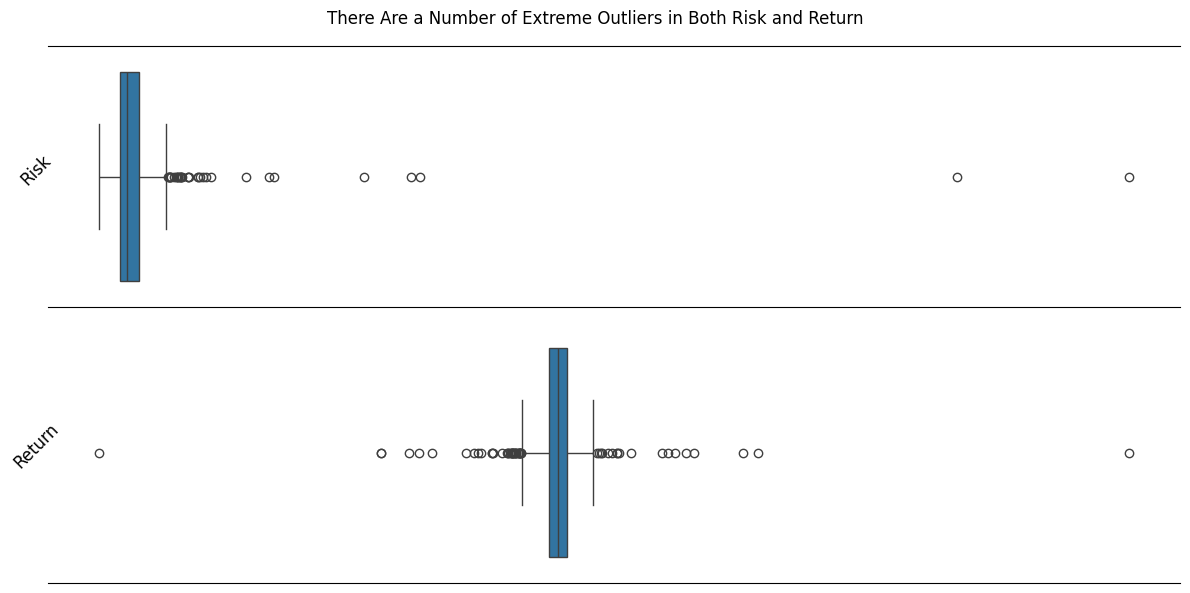

In [11]:
fig, ax = plt.subplots(2,1, figsize=(12,6), tight_layout=True)
plt.suptitle('There Are a Number of Extreme Outliers in Both Risk and Return')

ax[0].spines[['left','right']].set_visible(False)
ax[0].tick_params(top=False,
                  bottom=False,
                  left=False,
                  right=False,
                  labelleft=False,
                  labelbottom=False)
ax[0].set_ylabel('Risk', rotation=45, fontsize=12)
sns.boxplot(df_agg[['Risk']], ax=ax[0], orient='h')

ax[1].spines[['left','top','right']].set_visible(False)
ax[1].tick_params(top=False,
                  bottom=False,
                  left=False,
                  right=False,
                  labelleft=False,
                  labelbottom=False)
ax[1].set_ylabel('Return', rotation=45, fontsize=12)
sns.boxplot(df_agg[['Return']], ax=ax[1], orient='h')

plt.show();

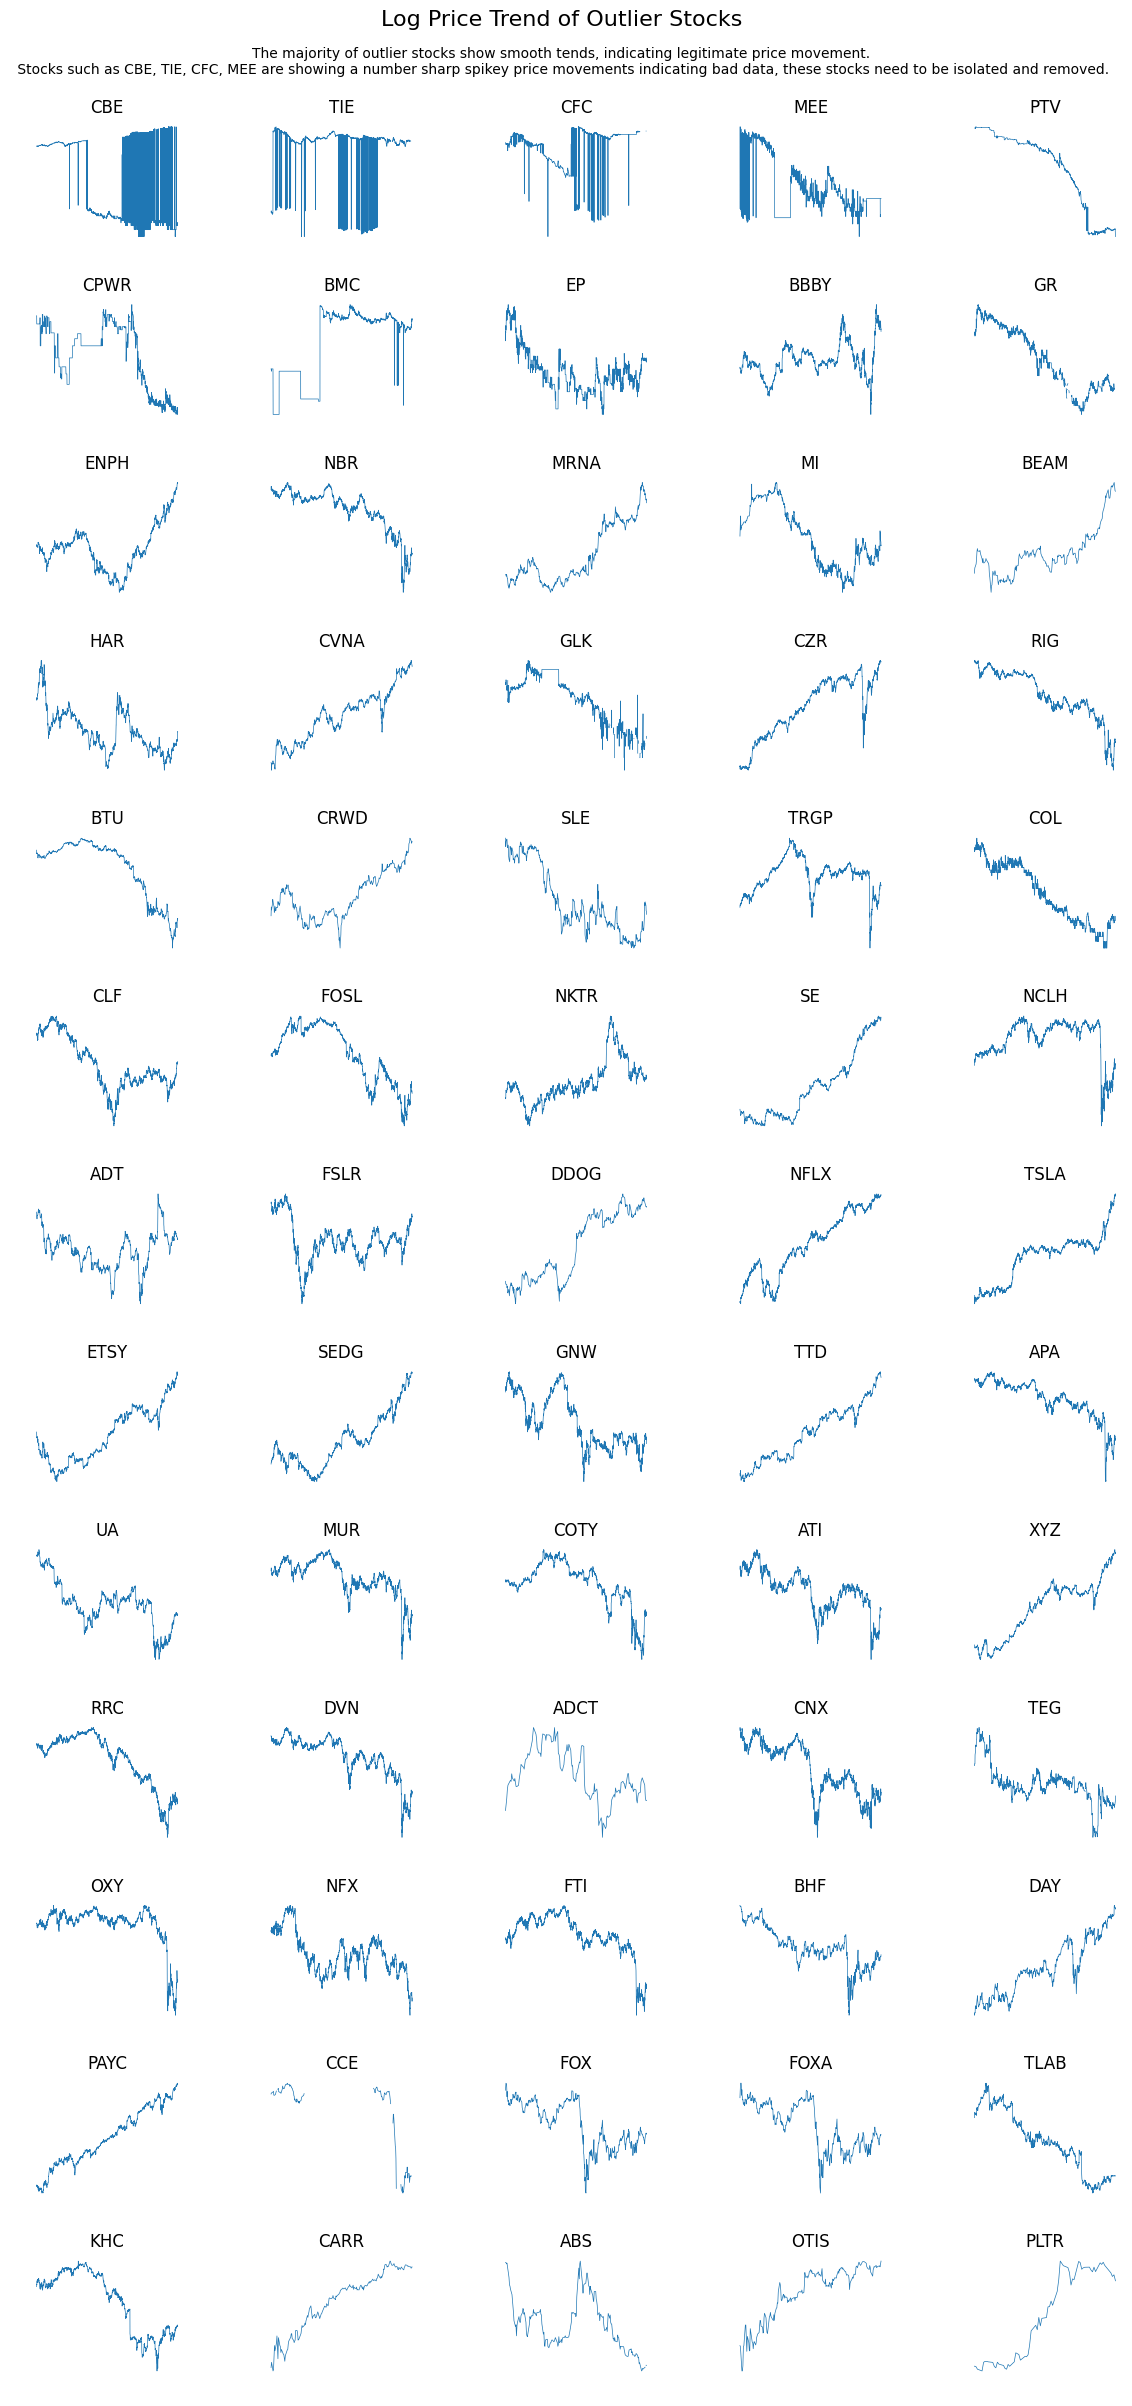

In [12]:
ncols = 5
nrows = int(np.ceil(len(outliers)/ncols))


fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2*nrows), tight_layout=True)

fig.tight_layout(pad=2, rect=[0,0.05,1,0.95])
fig.suptitle(f'Log Price Trend of Outlier Stocks', fontsize=16)
txt = 'The majority of outlier stocks show smooth tends, indicating legitimate price '\
      'movement.\n Stocks such as CBE, TIE, CFC, MEE are showing a number sharp spikey '\
      'price movements indicating bad data, these stocks need to be isolated and removed.'
fig.text(y=0.96,
         x=0.5,
         s=txt,
         horizontalalignment='center',
         verticalalignment='center')

for i, ticker in enumerate(outliers):

    ax = axes[int(i/5), i%5]
    ax.set_title(f"{ticker}")
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_ylabel(' ')
    ax.set_xticklabels([])
    ax.set_xticks([])
    ax.set_xlabel(' ')
    ax.spines[['top','bottom','left','right']].set_visible(False)

    ax.plot((log_prices[ticker]), linewidth=0.5)

# Determine how many empty plots there are on the last row of the figure
num_empty_plots = nrows * ncols - len(outliers)
if num_empty_plots > 0:
    for i in range(1, num_empty_plots + 1):
        # Hide empty plots
        axes[nrows - 1, ncols - i].set_axis_off()

## Isolating The Bad Data

In [13]:
# Daily Log Returns
log_returns = (log_prices - log_prices.shift(1))

#### Identifying Isolated Spikes

In [14]:
# Abnormaly large price changes directly both preceded and followed by
# comparatively small price movements.
isolated_spikes = (
    # Abnormaly large daily change (> 170%)
    abs(log_returns > 1).mask(log_returns.isna(), np.nan) &
    # Followed by a comparatively smally daily change (< 10.5%)
    (abs(log_returns.shift(1) < 0.1).mask(log_returns.isna(), np.nan) &
    # Preceded by a comparitively small daily change (< 10.5%)
     abs(log_returns.shift(-1) < 0.1).mask(log_returns.isna(), np.nan))
    ).sum()

#### Identifying Spikes with Immediate Reversal

In [15]:
# Abnormaly large price changes followed directly by an abnormaly large
# reversal.
reversal_spikes = (
    (((log_returns > 1) & (log_returns.shift(1) < -1)) | 
     ((log_returns < 1) & (log_returns.shift(1) > 1)))
).sum()

#### Identifying Large Residuals

In [16]:
# Identifying all abnormal price movements that deviate enourmously
# from the monthly median price
rolling_med = log_returns.rolling(21).median()
residual_spikes = (abs(log_returns - rolling_med) > 2).sum()

#### Combining

In [17]:
problem_counts = pd.concat(
    [isolated_spikes[isolated_spikes!=0],
     reversal_spikes[reversal_spikes!=0],
     residual_spikes[residual_spikes!=0]], 
    axis=1)\
        .fillna(0)\
            .astype(int)
problem_counts.columns = ['Isolated Spikes', 'Spike Reversals', 'Extreme Price Movements']
problem_tickers = problem_counts.index.tolist()
problem_counts

,Isolated Spikes,Spike Reversals,Extreme Price Movements
Ticker,,,
BMC,7,10,11
CBE,147,223,301
CFC,50,85,92
CPWR,7,8,2
EP,3,3,0
GLK,4,6,0
MEE,39,64,52
PTV,3,6,5
RSH,1,2,0


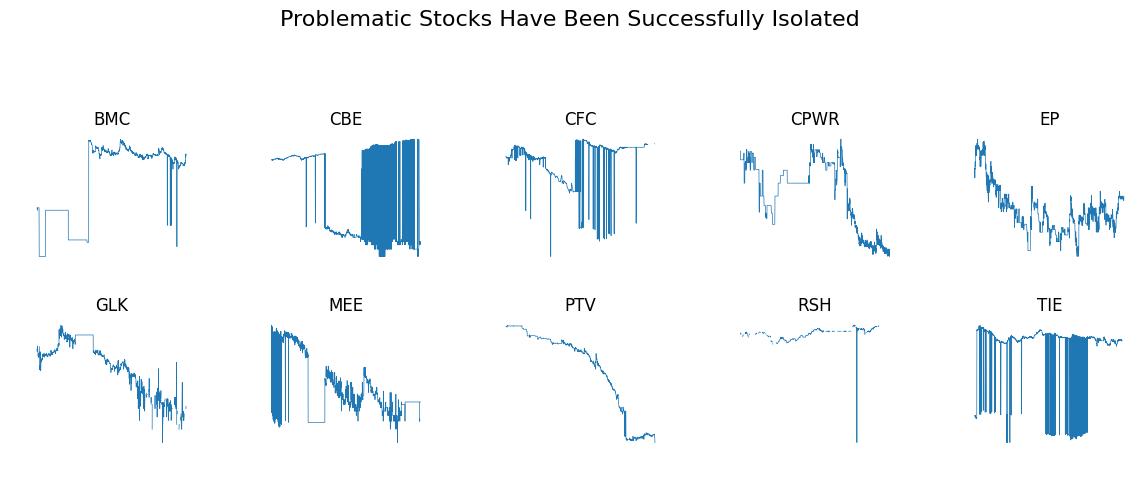

In [18]:
ncols = 5
nrows = int(np.ceil(len(problem_tickers)/ncols))


fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5), tight_layout=True)

fig.tight_layout(pad=2, rect=[0,0,1,0.8])
fig.suptitle(f'Problematic Stocks Have Been Successfully Isolated', fontsize=16)

for i, ticker in enumerate(problem_tickers):

    ax = axes[int(i/5), i%5]
    ax.set_title(f"{ticker}")
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_ylabel(' ')
    ax.set_xticklabels([])
    ax.set_xticks([])
    ax.set_xlabel(' ')
    ax.spines[['top','bottom','left','right']].set_visible(False)

    ax.plot((log_prices[ticker]), linewidth=0.5)

# Determine how many empty plots there are on the last row of the figure
num_empty_plots = nrows * ncols - len(problem_tickers)
if num_empty_plots > 0:
    for i in range(1, num_empty_plots + 1):
        # Hide empty plots
        axes[nrows - 1, ncols - i].set_axis_off()

## Removing Problem Stocks

In [19]:
df_stocks = df_stocks.drop(problem_tickers, axis=1, level=1)

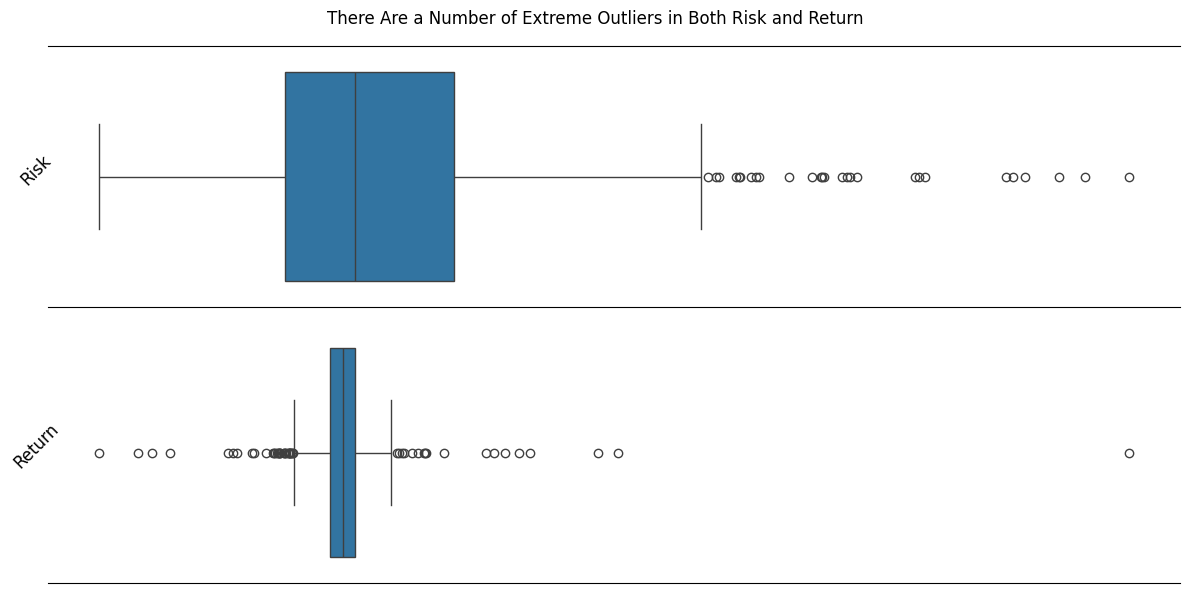

In [20]:
log_prices = np.log(df_stocks.Close)
ht(log_prices)
# 3 Month Rolling Returns
log_returns = log_prices - log_prices.shift(63)

# Calculate Log Risk / Return
df_agg = log_returns.agg({'mean', 'std'}).rename({'mean': 'Return', 'std': 'Risk'}).T

# Annualize Log Risk / Return
df_agg = df_agg * (np.sqrt(4), 4)
# Calculate Thresholds For Outliers
lq = df_agg.quantile(0.25)
uq = df_agg.quantile(0.75)
iqr = uq - lq
lo = lq - 1.5*iqr
uo = uq + 1.5*iqr

# Identify stocks that sit beyond outlier thresholds for risk or return
df_outliers = df_agg[((df_agg > uo) | (df_agg < lo))\
                     .any(axis=1)]\
                        .sort_values(['Risk', 'Return'], ascending=False)

# Save list of tickers of potential outliers
outliers = df_outliers.index.to_list()
df_outliers.head()
fig, ax = plt.subplots(2,1, figsize=(12,6), tight_layout=True)
plt.suptitle('There Are a Number of Extreme Outliers in Both Risk and Return')

ax[0].spines[['left','right']].set_visible(False)
ax[0].tick_params(top=False,
                  bottom=False,
                  left=False,
                  right=False,
                  labelleft=False,
                  labelbottom=False)
ax[0].set_ylabel('Risk', rotation=45, fontsize=12)
sns.boxplot(df_agg[['Risk']], ax=ax[0], orient='h')

ax[1].spines[['left','top','right']].set_visible(False)
ax[1].tick_params(top=False,
                  bottom=False,
                  left=False,
                  right=False,
                  labelleft=False,
                  labelbottom=False)
ax[1].set_ylabel('Return', rotation=45, fontsize=12)
sns.boxplot(df_agg[['Return']], ax=ax[1], orient='h')

plt.show();

## Identifying Tickers with Intermittent Data

<Axes: xlabel='Date'>

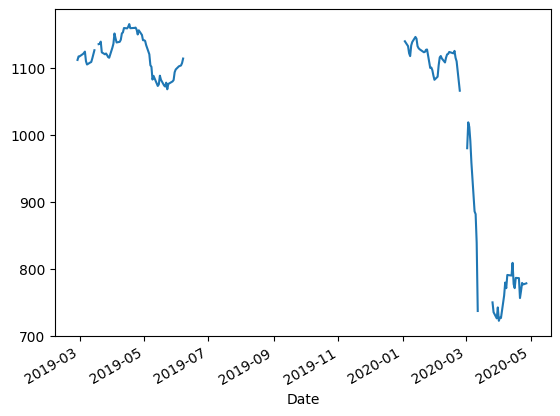

In [21]:
cce = df_stocks.Close['CCE']
cce.plot()

In [22]:
cce.first_valid_index()

Timestamp('2019-02-27 00:00:00')

In [23]:
cce.last_valid_index()

Timestamp('2020-04-29 00:00:00')

In [27]:
cce_valid = cce.loc[cce.first_valid_index(): cce.last_valid_index()]

<Axes: xlabel='Date'>

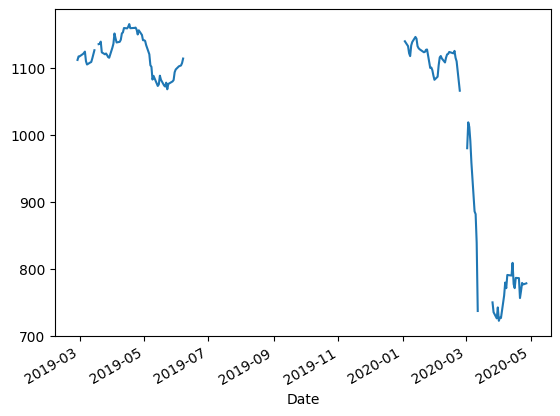

In [28]:
cce_valid.plot()

In [31]:
nulls = cce_valid.isna()

In [32]:
nulls.mean()

np.float64(0.5337837837837838)

In [34]:
nulls.cumsum()

Date
2019-02-27      0
2019-02-28      0
2019-03-01      0
2019-03-04      0
2019-03-05      0
             ... 
2020-04-23    157
2020-04-24    157
2020-04-27    157
2020-04-28    158
2020-04-29    158
Name: CCE, Length: 296, dtype: int64

In [99]:
nulls = pd.Series([0,0,1,0,0,1,1,1,1,0,0,1,1,0,0])
nulls

0     0
1     0
2     1
3     0
4     0
5     1
6     1
7     1
8     1
9     0
10    0
11    1
12    1
13    0
14    0
dtype: int64

In [109]:
((nulls.diff().fillna(nulls.iloc[0]) == 1) * 1).mask(nulls==False,np.nan).cumsum().value_counts().sort_index().agg(['mean', 'max', 'sum'])

mean    2.333333
max     4.000000
sum     7.000000
Name: count, dtype: float64

In [124]:
((cce_nulls.diff().fillna(cce_nulls.iloc[0]) == 1) * 1).mask(cce_nulls==False,np.nan).cumsum().value_counts().agg(['mean', 'max', 'sum', 'count']).astype(int)

mean      26
max      121
sum      158
count      6
Name: count, dtype: int64

In [129]:
((nulls.diff().fillna(nulls.iloc[0]) == 1) * 1).mask(nulls==False,np.nan)

0     NaN
1     NaN
2     1.0
3     NaN
4     NaN
5     1.0
6     0.0
7     0.0
8     0.0
9     NaN
10    NaN
11    1.0
12    0.0
13    NaN
14    NaN
dtype: float64

In [115]:
cce_nulls = cce_valid.isna() * 1

In [183]:
def get_nulls(s = pd.Series):
    
    start = s.first_valid_index()
    end = s.last_valid_index()
    
    if (start == None) | (end == None):
        return np.nan

    s_valid = s.loc[start: end].copy()
    
    nulls = s_valid.isna() * 1

    if nulls.sum() == 0:
        return np.nan
    
    nulls_periods =(
        ((nulls.diff().fillna(nulls.iloc[0]) == 1) * 1)\
            .mask(nulls==False,np.nan)\
                .cumsum())
    
    return nulls_periods.value_counts()\
                .agg(['mean', 'max', 'sum', 'count'])\
                    .astype(int)

In [184]:
stats = log_prices.apply(get_nulls)

In [189]:
stats[stats.notna()].to_frame()

,0
Ticker,
ABS,mean 1 max 1 sum 1 count 1 Na...
CCE,mean 26 max 121 sum 158 count ...
COL,mean 1 max 1 sum 41 count 4...
EVHC,mean 1 max 1 sum 1 count 1 Na...
GR,mean 2 max 15 sum 99 count 4...
HAR,mean 3 max 3 sum 3 count 1 Na...
MHS,mean 1 max 1 sum 14 count 1...
NFX,mean 1 max 1 sum 1 count 1 Na...
RX,mean 175 max 730 sum 1578 coun...


In [199]:
stats[stats.notna()].iloc[0]

mean     1
max      1
sum      1
count    1
Name: count, dtype: int64

In [205]:
s = stats[stats.notna()]

In [232]:
df_null = pd.DataFrame(s.tolist(), index=s.index)
df_null

,mean,max,sum,count
Ticker,,,,
ABS,1,1,1,1
CCE,26,121,158,6
COL,1,1,41,41
EVHC,1,1,1,1
GR,2,15,99,41
HAR,3,3,3,1
MHS,1,1,14,14
NFX,1,1,1,1
RX,175,730,1578,9


In [233]:
problem_tickers = df_null.index.tolist()

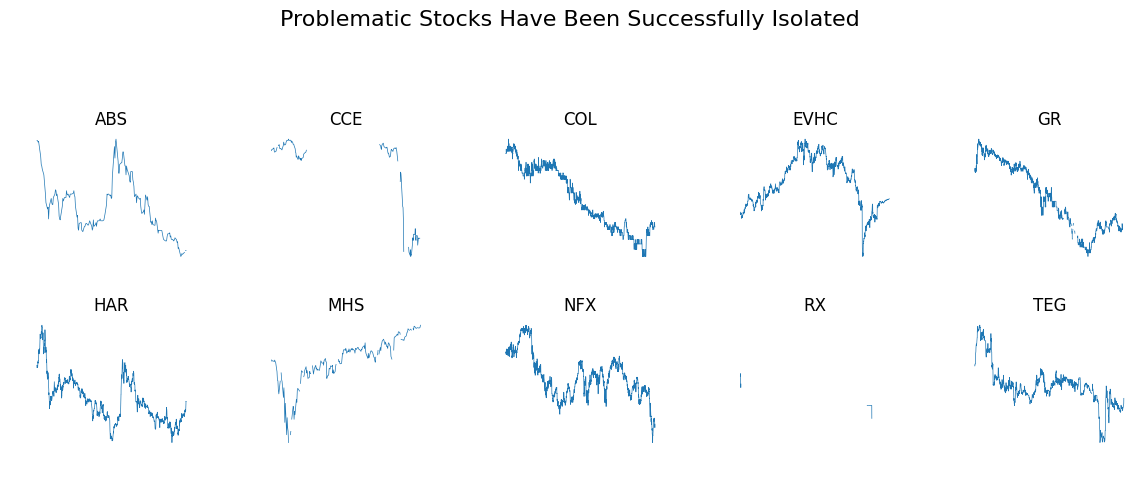

In [234]:
ncols = 5
nrows = int(np.ceil(len(problem_tickers)/ncols))


fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5), tight_layout=True)

fig.tight_layout(pad=2, rect=[0,0,1,0.8])
fig.suptitle(f'Problematic Stocks Have Been Successfully Isolated', fontsize=16)

for i, ticker in enumerate(problem_tickers):

    ax = axes[int(i/5), i%5]
    ax.set_title(f"{ticker}")
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_ylabel(' ')
    ax.set_xticklabels([])
    ax.set_xticks([])
    ax.set_xlabel(' ')
    ax.spines[['top','bottom','left','right']].set_visible(False)

    ax.plot((log_prices[ticker]), linewidth=0.5)

# Determine how many empty plots there are on the last row of the figure
num_empty_plots = nrows * ncols - len(problem_tickers)
if num_empty_plots > 0:
    for i in range(1, num_empty_plots + 1):
        # Hide empty plots
        axes[nrows - 1, ncols - i].set_axis_off()

<Axes: xlabel='Date'>

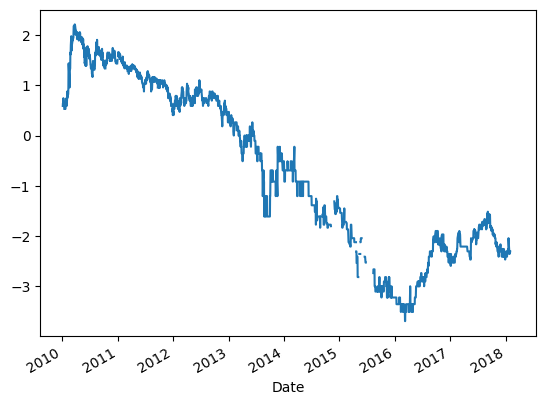

In [244]:
s = log_prices['GR'].loc[log_prices['GR'].first_valid_index(): log_prices['GR'].last_valid_index()]
s.plot()

<Axes: xlabel='Date'>

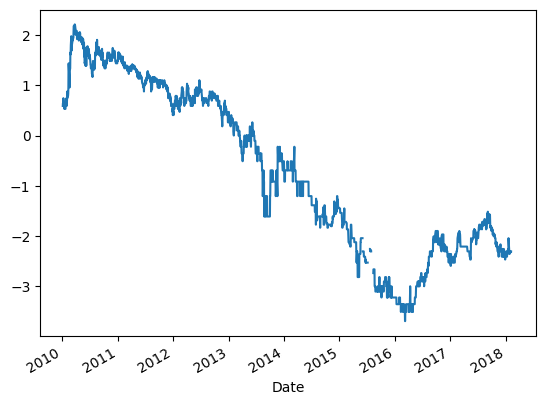

In [248]:
s.fillna(s.rolling(5, min_periods=1).median()).plot()

In [247]:
s.fillna(s.rolling(7, min_periods=1).median()).isna().any()

np.True_

<Axes: xlabel='Date'>

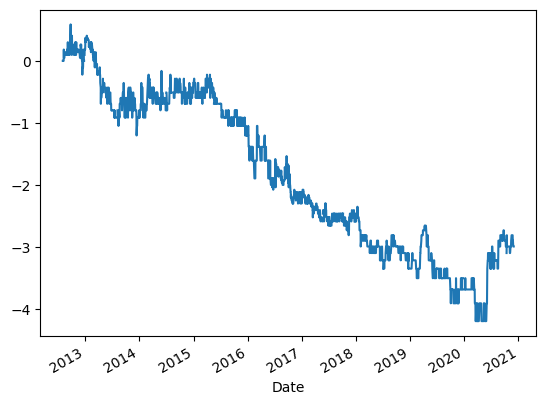

In [237]:
log_prices['COL'].loc[log_prices['COL'].first_valid_index(): log_prices['COL'].last_valid_index()].plot()